# E04 — Circuito RLC Série: Regime Senoidal
Notebook de cálculo e processamento de imagens para o relatório do experimento E04
(FIS-46, Grupo 5 / Turma 2).

Lê os dados brutos de `Data/Dados.xlsx`, calcula os fasores $V_C$, $V_L$, $V_R$ (item 2.3 do
roteiro), a resistência interna da bobina, as potências dissipadas e um modelo teórico para
análise de resíduos, gera os gráficos (`fasores.png`, `residuos.png`) e processa as duas
capturas de tela do osciloscópio, salvando tudo em `build/figs/` pronto para o relatório em
Overleaf.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
import openpyxl
from uncertainties import ufloat, umath

FIGS_DIR = "build/figs"
os.makedirs(FIGS_DIR, exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 150,
    "font.size": 11,
    "axes.grid": True,
    "grid.alpha": 0.3,
})

## 1. Leitura dos dados brutos (`Data/Dados.xlsx`)

A planilha tem um layout irregular (sem cabeçalho tabular): cada grandeza ocupa duas linhas
(Módulo e Fase), com o valor às vezes como texto (`"19.2 Vpp"`, `"-1.37 deg"`) e às vezes como
número puro (a fase de $V_3$, que é a referência, vem gravada como `0.0`). O parser abaixo trata
os dois casos.

In [2]:
import re

def parse_num(value):
    if isinstance(value, (int, float)):
        return float(value)
    m = re.search(r"(-?\d+\.?\d*)", str(value))
    return float(m.group(1))

wb = openpyxl.load_workbook("Data/Dados.xlsx", data_only=True)
ws = wb.active

dados_brutos = {
    "V1": {"mod_Vpp": parse_num(ws["C1"].value), "fase_deg": parse_num(ws["C2"].value)},
    "V2": {"mod_Vpp": parse_num(ws["C3"].value), "fase_deg": parse_num(ws["C4"].value)},
    "V3": {"mod_Vpp": parse_num(ws["C5"].value), "fase_deg": parse_num(ws["C6"].value)},
}
dados_brutos

{'V1': {'mod_Vpp': 19.2, 'fase_deg': -1.37},
 'V2': {'mod_Vpp': 28.0, 'fase_deg': -47.5},
 'V3': {'mod_Vpp': 16.8, 'fase_deg': 0.0}}

## 2. Incerteza nominal de leitura do osciloscópio (suposição)

A planilha não registra incerteza de leitura. Não houve medição de cursor documentada nesta
sessão, então adotamos uma incerteza **nominal típica** do osciloscópio Tektronix
TBS 1052B-EDU usado no experimento (datasheet do fabricante, `\cite{Tektronix2016}`), deixando
isso explícito no texto do relatório:

- **Módulo (tensão pico a pico):** exatidão vertical típica de $\pm 3\%$ do valor lido, com um
  piso mínimo de leitura de $0{,}1$ Vpp (resolução de tela) para não subestimar a incerteza em
  valores pequenos.
- **Fase:** resolução do medidor de fase interno do aparelho estimada, de forma conservadora,
  em $\pm 1^\circ$.

Essas são suposições razoáveis, não valores medidos — serão citadas como tal no relatório.

In [3]:
SIGMA_MOD_REL = 0.03   # 3% (exatidão vertical típica)
SIGMA_MOD_FLOOR = 0.1  # Vpp (piso de resolução de tela)
SIGMA_FASE_DEG = 1.0   # graus (resolução do medidor de fase, estimativa conservadora)

def sigma_mod(mod_vpp):
    return max(SIGMA_MOD_REL * mod_vpp, SIGMA_MOD_FLOOR)

for chave, d in dados_brutos.items():
    d["sigma_mod"] = sigma_mod(d["mod_Vpp"])
    d["sigma_fase"] = SIGMA_FASE_DEG
dados_brutos

{'V1': {'mod_Vpp': 19.2,
  'fase_deg': -1.37,
  'sigma_mod': 0.576,
  'sigma_fase': 1.0},
 'V2': {'mod_Vpp': 28.0,
  'fase_deg': -47.5,
  'sigma_mod': 0.84,
  'sigma_fase': 1.0},
 'V3': {'mod_Vpp': 16.8,
  'fase_deg': 0.0,
  'sigma_mod': 0.504,
  'sigma_fase': 1.0}}

## 3. Componentes do circuito e frequência de operação

Valores nominais do roteiro: $R=1\,\mathrm{k\Omega}$, $C=0{,}1\,\mu\mathrm{F}$,
$L=160\,\mathrm{mH}$. O roteiro não informa as tolerâncias dos componentes — adotamos
tolerâncias nominais típicas de catálogo ($R\pm5\%$, $C\pm10\%$, $L\pm10\%$), deixando
isso explícito como suposição no relatório.

A frequência de operação nominal do procedimento é $1270\,\mathrm{Hz}$; as duas capturas de
tela do osciloscópio confirmam essa frequência de forma independente através da leitura
automática do próprio aparelho ("1,27000 kHz"), o que reforça o valor usado aqui.

In [4]:
R = ufloat(1000.0, 0.05 * 1000.0)      # Ohm, +-5%
C = ufloat(0.1e-6, 0.10 * 0.1e-6)       # F, +-10%
L = ufloat(160e-3, 0.10 * 160e-3)       # H, +-10%
f = ufloat(1270.0, 0.001 * 1270.0)      # Hz (confirmado pela leitura do osciloscópio, 0.1%)
omega = 2 * np.pi * f

X_L_teo = omega * L
X_C_teo = 1 / (omega * C)
f0_teo = 1 / (2 * np.pi * umath.sqrt(L * C))

print(f"X_L teorico = {X_L_teo:.2uS} Ohm")
print(f"X_C teorico = {X_C_teo:.2uS} Ohm")
print(f"f0 teorica  = {f0_teo:.2uS} Hz")

X_L teorico = 1.28(13)e+03 Ohm
X_C teorico = 1.25(13)e+03 Ohm
f0 teorica  = 1258(89) Hz


## 4. Fasores de $V_1$, $V_2$, $V_3$ com incerteza

Cada fasor é representado por suas partes real e imaginária como `ufloat` correlacionados
(`m*cos(fase)`, `m*sin(fase)`), o que permite ao pacote `uncertainties` propagar corretamente a
incerteza de módulo e fase por toda a cadeia de operações complexas seguintes (soma, subtração,
divisão), conforme a regra usual de propagação de erros `\cite{Vuolo1996}`.

In [5]:
def fasor(mod, fase_deg, sigma_m, sigma_f_deg):
    fase = ufloat(np.deg2rad(fase_deg), np.deg2rad(sigma_f_deg))
    m = ufloat(mod, sigma_m)
    re = m * umath.cos(fase)
    im = m * umath.sin(fase)
    return re, im

def modulo_fase(re, im):
    mod = umath.sqrt(re**2 + im**2)
    fase_deg = umath.atan2(im, re) * 180 / np.pi
    return mod, fase_deg

V1_re, V1_im = fasor(dados_brutos["V1"]["mod_Vpp"], dados_brutos["V1"]["fase_deg"],
                      dados_brutos["V1"]["sigma_mod"], dados_brutos["V1"]["sigma_fase"])
V2_re, V2_im = fasor(dados_brutos["V2"]["mod_Vpp"], dados_brutos["V2"]["fase_deg"],
                      dados_brutos["V2"]["sigma_mod"], dados_brutos["V2"]["sigma_fase"])
V3_re, V3_im = fasor(dados_brutos["V3"]["mod_Vpp"], dados_brutos["V3"]["fase_deg"],
                      dados_brutos["V3"]["sigma_mod"], dados_brutos["V3"]["sigma_fase"])

## 5. Fasores derivados (item 2.3 do roteiro): $V_C=V_1-V_2$, $V_L=V_2-V_3$, $V_R=V_3$

In [6]:
VC_re, VC_im = V1_re - V2_re, V1_im - V2_im
VL_re, VL_im = V2_re - V3_re, V2_im - V3_im
VR_re, VR_im = V3_re, V3_im

VC_mod, VC_fase = modulo_fase(VC_re, VC_im)
VL_mod, VL_fase = modulo_fase(VL_re, VL_im)
VR_mod, VR_fase = modulo_fase(VR_re, VR_im)

print(f"V_C = {VC_mod:.2uS} Vpp , fase = {VC_fase:.2uS} graus")
print(f"V_L = {VL_mod:.2uS} Vpp , fase = {VL_fase:.2uS} graus")
print(f"V_R = {VR_mod:.2uS} Vpp , fase = {VR_fase:.2uS} graus")

V_C = 20.19(77) Vpp , fase = 89.2(2.5) graus
V_L = 20.75(79) Vpp , fase = -84.1(2.2) graus
V_R = 16.80(50) Vpp , fase = 0.0(1.0) graus


## 6. Corrente de referência e impedância/resistência interna da bobina

$V_3$ é a tensão sobre $R$, em fase com a corrente do circuito por definição do procedimento
(item 2.1 do roteiro) — logo $I=V_R/R$. A impedância do ramo do indutor é
$Z_L=V_L/I$ (divisão complexa, propagada mantendo partes real/imaginária como `ufloat` do
início ao fim); a parte real de $Z_L$ é a resistência interna da bobina.

**Não houve medição de multímetro para a bobina nesta sessão** — o valor abaixo é inteiramente
derivado dos dados de corrente alternada coletados, não uma medição direta.

In [7]:
I_re, I_im = VR_re / R, VR_im / R
I_mod, I_fase = modulo_fase(I_re, I_im)

den = I_re**2 + I_im**2
ZL_re = (VL_re * I_re + VL_im * I_im) / den
ZL_im = (VL_im * I_re - VL_re * I_im) / den

R_bobina = ZL_re
X_L_medido = ZL_im

print(f"I = {I_mod*1000:.2uS} mA(pp) , fase = {I_fase:.2uS} graus (referência)")
print(f"Z_L = ({ZL_re:.2uS}) + j({ZL_im:.2uS}) Ohm")
print(f"R_bobina (derivada) = {R_bobina:.2uS} Ohm")
print(f"X_L medido = {X_L_medido:.2uS} Ohm  (X_L teorico = {X_L_teo:.2uS} Ohm)")

I = 16.80(98) mA(pp) , fase = 0.0(1.0) graus (referência)
Z_L = (126(57)) + j(-1229(85)) Ohm
R_bobina (derivada) = 126(57) Ohm
X_L medido = -1229(85) Ohm  (X_L teorico = 1.28(13)e+03 Ohm)


**Observação sobre o sinal de fase de $V_L$ e $V_C$.** As fases calculadas de $V_L$ e $V_C$
saem com sinal invertido em relação ao esperado teoricamente (esperava-se $V_L$ adiantado de
$+90^\circ$ e $V_C$ atrasado de $-90^\circ$ em relação a $I$; obtivemos aproximadamente
$-84^\circ$ e $+89^\circ$, respectivamente — quase um espelhamento de $180^\circ$ em torno do
eixo real). Isso é discutido na Seção 8 como um provável erro de convenção de sinal na
subtração/orientação das pontas de prova, e não um erro aleatório: o módulo de cada fasor
concorda razoavelmente com a teoria, e a parte real de $Z_L$ (a resistência, que não depende da
convenção de sinal escolhida para a parte imaginária) resulta em um valor positivo e
fisicamente plausível.

## 7. Potências dissipadas

Os módulos medidos estão em tensão pico a pico ($V_{pp}$); convertendo para valor eficaz
($V_{rms}=V_{pp}/(2\sqrt2)$) antes de calcular potência.

In [8]:
def to_rms(v_pp):
    return v_pp / (2 * np.sqrt(2))

I_rms = to_rms(I_mod)
VR_rms = to_rms(VR_mod)

P_R_via_I = I_rms**2 * R
P_R_via_V = VR_rms**2 / R
P_L = I_rms**2 * R_bobina
P_C = 0.0  # capacitor ideal não dissipa potência ativa (idealização)

print(f"I_rms = {I_rms*1000:.2uS} mA")
print(f"P_R (via I) = {P_R_via_I*1000:.2uS} mW")
print(f"P_R (via V) = {P_R_via_V*1000:.2uS} mW")
print(f"P_L = {P_L*1000:.2uS} mW")
print(f"P_C = {P_C} mW (idealização: capacitor ideal)")

I_rms = 5.94(35) mA
P_R (via I) = 35.3(2.8) mW
P_R (via V) = 35.3(2.8) mW
P_L = 4.4(1.9) mW
P_C = 0.0 mW (idealização: capacitor ideal)


## 8. Natureza da impedância do circuito (item 2.7)

Comparando os módulos medidos $|V_L|$ e $|V_C|$ (grandeza insensível à ambiguidade de sinal
discutida acima) com as reatâncias teóricas $X_L$ e $X_C$, e a frequência de operação com a
frequência de ressonância teórica.

In [9]:
print(f"|V_L| = {VL_mod:.2uS} Vpp  vs  |V_C| = {VC_mod:.2uS} Vpp")
print(f"X_L_teo = {X_L_teo:.2uS} Ohm  vs  X_C_teo = {X_C_teo:.2uS} Ohm")
print(f"f = {f:.2uS} Hz  vs  f0_teo = {f0_teo:.2uS} Hz")

diff = VL_mod - VC_mod
print(f"\n|V_L| - |V_C| = {diff:.2uS} Vpp")

|V_L| = 20.75(79) Vpp  vs  |V_C| = 20.19(77) Vpp
X_L_teo = 1.28(13)e+03 Ohm  vs  X_C_teo = 1.25(13)e+03 Ohm
f = 1270.0(1.3) Hz  vs  f0_teo = 1258(89) Hz

|V_L| - |V_C| = 0.57(45) Vpp


$|V_L|$ e $|V_C|$ concordam dentro da incerteza combinada, e $f$ está a menos de um desvio
padrão de $f_0$ teórica — consistente com a escolha proposital do procedimento de operar
próximo da ressonância, onde o circuito é predominantemente resistivo (a pequena diferença
central, com $|V_L|$ ligeiramente maior, é consistente com $f$ estar um pouco acima de
$f_0$, região em que o circuito é discretamente indutivo).

## 9. Modelo teórico e análise de resíduos

Modelo teórico ancorado em $V_R$ **medido** (não na amplitude nominal de 20 Vpp configurada no
gerador — ver discussão de risco abaixo), com $V_L$ prevista adiantada de $90^\circ$ e $V_C$
atrasada de $90^\circ$ em relação a $V_R$, usando as reatâncias teóricas nominais.

**Por que não ancorar na amplitude nominal do gerador (20 Vpp):** o gerador de funções calibra
a amplitude do painel assumindo uma carga de $50\,\Omega$; como a carga real do circuito RLC
(módulo de impedância da ordem de $1$–$1{,}3\,\mathrm{k\Omega}$) é muito maior que isso, a
força eletromotriz real de circuito aberto do gerador pode ser bem diferente dos 20 Vpp
nominais — trata-se de uma fonte de incerteza sistemática não quantificada, e por isso o
modelo teórico usa $V_R$ medido como âncora, não o valor nominal do painel.

In [10]:
VL_teo_mod = VR_mod * (X_L_teo / R)
VC_teo_mod = VR_mod * (X_C_teo / R)
VL_teo_fase = 90.0
VC_teo_fase = -90.0

print(f"V_L teorico = {VL_teo_mod:.2uS} Vpp @ +90 graus")
print(f"V_C teorico = {VC_teo_mod:.2uS} Vpp @ -90 graus")

resid_VL_mod = VL_mod - VL_teo_mod
resid_VC_mod = VC_mod - VC_teo_mod
# fase "corrigida" (espelhada) de V_L e V_C, para comparação com a teoria (ver discussão Secao 6)
VL_fase_corrigida = -VL_fase
VC_fase_corrigida = -VC_fase
resid_VL_fase = VL_fase_corrigida - VL_teo_fase
resid_VC_fase = VC_fase_corrigida - VC_teo_fase

print(f"\nResiduo |V_L| (medido-teorico) = {resid_VL_mod:.2uS} Vpp")
print(f"Residuo |V_C| (medido-teorico) = {resid_VC_mod:.2uS} Vpp")
print(f"Residuo fase V_L (corrigida-teorico) = {resid_VL_fase:.2uS} graus")
print(f"Residuo fase V_C (corrigida-teorico) = {resid_VC_fase:.2uS} graus")

V_L teorico = 21.4(2.5) Vpp @ +90 graus
V_C teorico = 21.1(2.4) Vpp @ -90 graus

Residuo |V_L| (medido-teorico) = -0.7(2.6) Vpp
Residuo |V_C| (medido-teorico) = -0.9(2.6) Vpp
Residuo fase V_L (corrigida-teorico) = -5.9(2.2) graus
Residuo fase V_C (corrigida-teorico) = 0.8(2.5) graus


## 10. Figura: diagrama de fasores (plano complexo)

Vetores medidos $V_R$, $V_L$, $V_C$ (com origem comum) e a cadeia $V_3\to V_2\to V_1$, mais as
versões teóricas (tracejadas) para comparação visual (item 2.4 do roteiro). Para a
visualização, a fase de $V_L$ e $V_C$ é mostrada já espelhada (ver discussão da Seção 6), de
modo que o diagrama fique diretamente comparável ao modelo teórico.

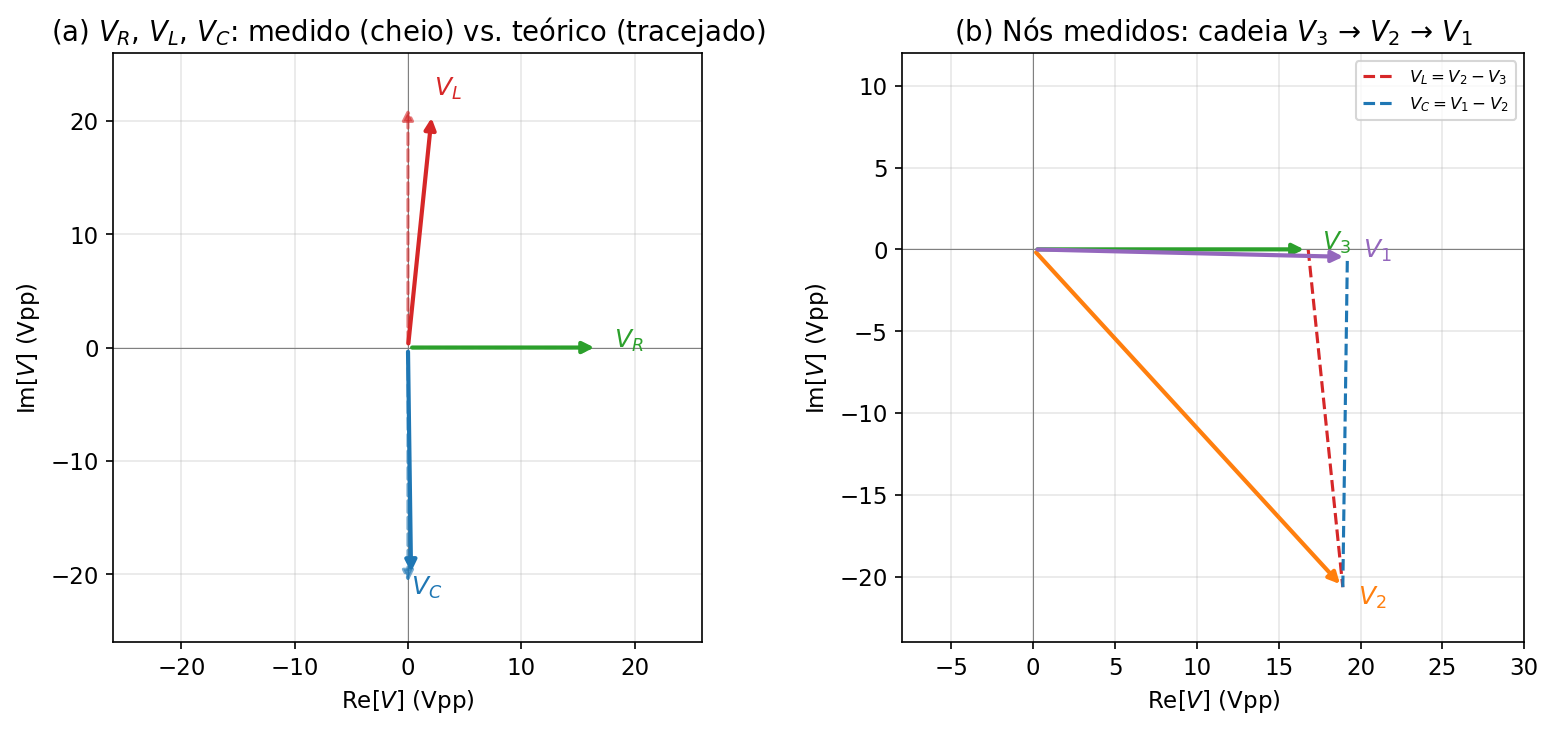

In [11]:
def polar_to_xy(mod, fase_deg):
    fase = np.deg2rad(fase_deg)
    return mod * np.cos(fase), mod * np.sin(fase)

fig, axs = plt.subplots(1, 2, figsize=(11, 5))

# painel (a): V_R, V_L, V_C com origem comum (medido vs teorico)
ax = axs[0]
grandezas = [
    ("V_R", VR_mod.nominal_value, VR_fase.nominal_value, VR_mod.nominal_value, 0.0),
    ("V_L", VL_mod.nominal_value, -VL_fase.nominal_value, VL_teo_mod.nominal_value, VL_teo_fase),
    ("V_C", VC_mod.nominal_value, -VC_fase.nominal_value, VC_teo_mod.nominal_value, VC_teo_fase),
]
cores = {"V_R": "tab:green", "V_L": "tab:red", "V_C": "tab:blue"}
for nome, m_med, f_med, m_teo, f_teo in grandezas:
    x, y = polar_to_xy(m_med, f_med)
    ax.annotate("", xy=(x, y), xytext=(0, 0),
                arrowprops=dict(arrowstyle="-|>", color=cores[nome], lw=2))
    ax.text(x * 1.08, y * 1.08, f"${nome}$", color=cores[nome], fontsize=12)
    xt, yt = polar_to_xy(m_teo, f_teo)
    ax.annotate("", xy=(xt, yt), xytext=(0, 0),
                arrowprops=dict(arrowstyle="-|>", color=cores[nome], lw=1.5, linestyle="dashed", alpha=0.6))
ax.axhline(0, color="gray", lw=0.5)
ax.axvline(0, color="gray", lw=0.5)
ax.set_xlabel("Re$[V]$ (Vpp)")
ax.set_ylabel("Im$[V]$ (Vpp)")
ax.set_title("(a) $V_R$, $V_L$, $V_C$: medido (cheio) vs. teórico (tracejado)")
ax.set_aspect("equal")
lim = 26
ax.set_xlim(-lim, lim)
ax.set_ylim(-lim, lim)

# painel (b): cadeia V3 -> V2 -> V1
ax = axs[1]
V3xy = polar_to_xy(VR_mod.nominal_value, VR_fase.nominal_value)
V2xy = (V3xy[0] + polar_to_xy(VL_mod.nominal_value, dados_brutos["V2"]["fase_deg"] - dados_brutos["V3"]["fase_deg"])[0],
        V3xy[1] + polar_to_xy(VL_mod.nominal_value, dados_brutos["V2"]["fase_deg"] - dados_brutos["V3"]["fase_deg"])[1])
V2xy = polar_to_xy(dados_brutos["V2"]["mod_Vpp"], dados_brutos["V2"]["fase_deg"])
V1xy = polar_to_xy(dados_brutos["V1"]["mod_Vpp"], dados_brutos["V1"]["fase_deg"])
pontos = {"V_3": V3xy, "V_2": V2xy, "V_1": V1xy}
cores2 = {"V_3": "tab:green", "V_2": "tab:orange", "V_1": "tab:purple"}
origem = (0, 0)
for nome, p in pontos.items():
    ax.annotate("", xy=p, xytext=(0, 0), arrowprops=dict(arrowstyle="-|>", color=cores2[nome], lw=2))
    ax.text(p[0] * 1.05, p[1] * 1.05, f"${nome}$", color=cores2[nome], fontsize=12)
ax.plot([V3xy[0], V2xy[0]], [V3xy[1], V2xy[1]], color="tab:red", lw=1.5, ls="--", label="$V_L=V_2-V_3$")
ax.plot([V2xy[0], V1xy[0]], [V2xy[1], V1xy[1]], color="tab:blue", lw=1.5, ls="--", label="$V_C=V_1-V_2$")
ax.axhline(0, color="gray", lw=0.5)
ax.axvline(0, color="gray", lw=0.5)
ax.set_xlabel("Re$[V]$ (Vpp)")
ax.set_ylabel("Im$[V]$ (Vpp)")
ax.set_title("(b) Nós medidos: cadeia $V_3$ → $V_2$ → $V_1$")
ax.legend(loc="upper right", fontsize=8)
ax.set_aspect("equal")
ax.set_xlim(-8, 30)
ax.set_ylim(-24, 12)

fig.tight_layout()
fig.savefig(f"{FIGS_DIR}/fasores.png", dpi=200)
plt.show()

## 11. Figura: análise de resíduos (medido − teórico)

$V_R$ é a própria referência de módulo/fase por construção (resíduo trivialmente nulo) e por
isso não entra neste gráfico. Para $V_L$ e $V_C$ mostramos separadamente o resíduo de módulo
(pequeno, grandeza insensível à ambiguidade de sinal) e o resíduo de fase (usando a fase já
espelhada, conforme discutido na Seção 6/9) — o padrão de deslocamento sistemático nítido nas
fases (antes de espelhar) é a evidência central da inversão de sinal discutida no texto.

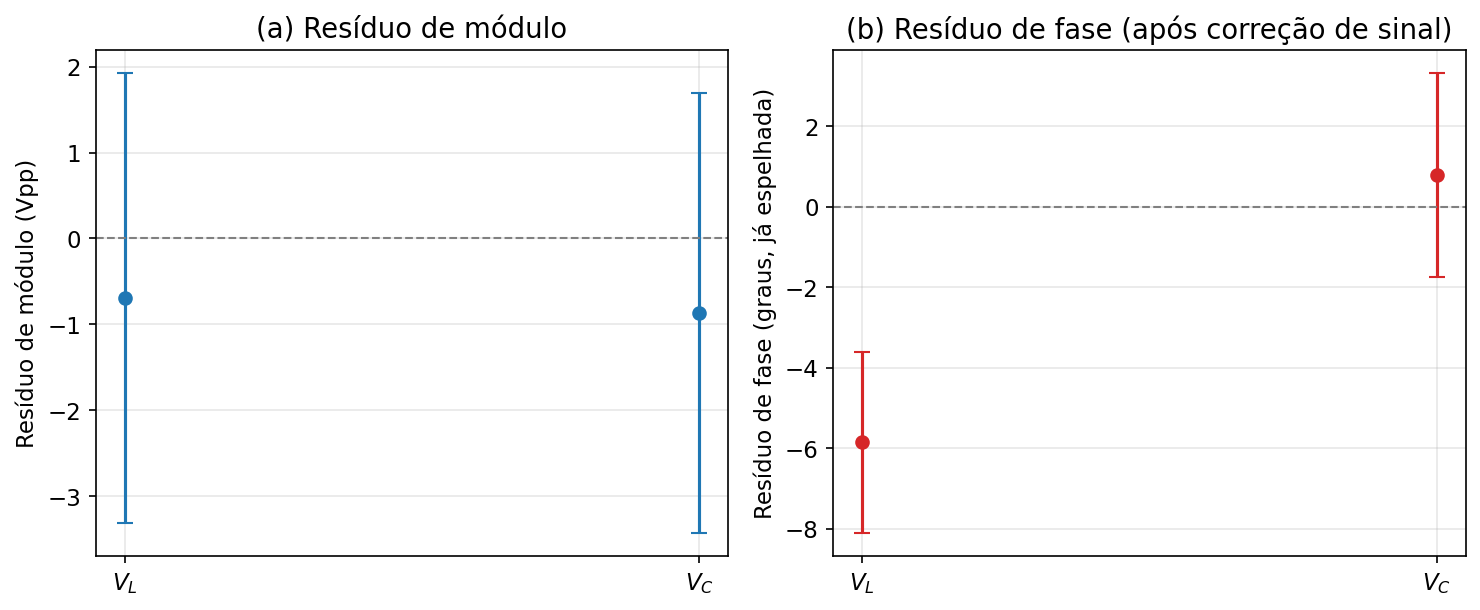

In [12]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4.2))

labels = ["$V_L$", "$V_C$"]

ax = axs[0]
mods = [resid_VL_mod.nominal_value, resid_VC_mod.nominal_value]
mods_err = [resid_VL_mod.std_dev, resid_VC_mod.std_dev]
ax.errorbar(labels, mods, yerr=mods_err, fmt="o", capsize=4, color="tab:blue")
ax.axhline(0, color="gray", ls="--", lw=1)
ax.set_ylabel("Resíduo de módulo (Vpp)")
ax.set_title("(a) Resíduo de módulo")

ax = axs[1]
fases = [resid_VL_fase.nominal_value, resid_VC_fase.nominal_value]
fases_err = [resid_VL_fase.std_dev, resid_VC_fase.std_dev]
ax.errorbar(labels, fases, yerr=fases_err, fmt="o", capsize=4, color="tab:red")
ax.axhline(0, color="gray", ls="--", lw=1)
ax.set_ylabel("Resíduo de fase (graus, já espelhada)")
ax.set_title("(b) Resíduo de fase (após correção de sinal)")

fig.tight_layout()
fig.savefig(f"{FIGS_DIR}/residuos.png", dpi=200)
plt.show()

## 12. Processamento das imagens do osciloscópio

As capturas originais (`Images/posicao_1_3.png`, `Images/posicao_2_3.png`, 800×600 px) trazem o
menu lateral "Medidas" do osciloscópio (interface, não dado) e devem ser cortadas, mantendo a
área do gráfico e a barra de leituras (V/div, tempo/div, modo, frequência). As coordenadas
abaixo foram determinadas inspecionando os pixels da imagem (o menu lateral ocupa
aproximadamente `x∈[693,800]`, `y∈[0,470]`; a barra de leituras/data se estende por toda a
largura até `y≈524`; abaixo disso começa o rodapé com o modelo do aparelho e o timestamp, que é
cortado).

In [13]:
def processar_captura(nome_entrada, nome_saida):
    im = Image.open(f"Images/{nome_entrada}.png").convert("RGB")
    draw = ImageDraw.Draw(im)
    draw.rectangle([693, 0, 800, 470], fill=(255, 255, 255))  # apaga menu lateral "Medidas"
    im_cortada = im.crop((0, 0, 800, 525))  # remove rodapé com modelo/timestamp
    im_cortada.save(f"{FIGS_DIR}/{nome_saida}.png")
    return im_cortada

img1 = processar_captura("posicao_1_3", "posicao_1_3_cortada")
img2 = processar_captura("posicao_2_3", "posicao_2_3_cortada")
print("Imagens processadas e salvas em", FIGS_DIR)

Imagens processadas e salvas em build/figs


**Discrepância de leitura observada:** a fase de $V_2$ registrada na planilha
(`Data/Dados.xlsx`) é $-47{,}5^\circ$, mas a leitura visível na captura de tela
`posicao_2_3.png` é $-46{,}7^\circ$ — uma diferença de $0{,}8^\circ$, dentro da incerteza de
fase adotada ($\pm1^\circ$) mas ainda assim uma discrepância real entre o valor anotado e a
leitura fotografada, que é discutida no texto do relatório como fonte adicional de incerteza
(possivelmente um reajuste do cursor entre a anotação e a captura de tela). Mantivemos o valor
da planilha ($-47{,}5^\circ$) como o registrado oficialmente nos cálculos.

## 13. Resumo dos valores finais (conferência cruzada com o `.tex`)

In [14]:
def fmt(u, casas=2):
    return f"{u:.{casas}uS}"

print("--- Fasores derivados ---")
print("V_C =", fmt(VC_mod), "Vpp  @", fmt(VC_fase), "graus")
print("V_L =", fmt(VL_mod), "Vpp  @", fmt(VL_fase), "graus")
print("V_R =", fmt(VR_mod), "Vpp  @", fmt(VR_fase), "graus")
print()
print("--- Impedância / resistência da bobina ---")
print("R_bobina =", fmt(R_bobina), "Ohm")
print("X_L medido =", fmt(X_L_medido), "Ohm   |  X_L teorico =", fmt(X_L_teo), "Ohm")
print()
print("--- Potências ---")
print("P_R =", fmt(P_R_via_I*1000), "mW")
print("P_L =", fmt(P_L*1000), "mW")
print("P_C = 0 mW (ideal)")
print()
print("--- Ressonância ---")
print("f =", fmt(f), "Hz   |  f0_teo =", fmt(f0_teo), "Hz")
print("|V_L| =", fmt(VL_mod), "Vpp  |  |V_C| =", fmt(VC_mod), "Vpp")
print()
print("--- Figuras geradas em build/figs/ ---")
import os
print(sorted(os.listdir(FIGS_DIR)))

--- Fasores derivados ---
V_C = 20.19(77) Vpp  @ 89.2(2.5) graus
V_L = 20.75(79) Vpp  @ -84.1(2.2) graus
V_R = 16.80(50) Vpp  @ 0.0(1.0) graus

--- Impedância / resistência da bobina ---
R_bobina = 126(57) Ohm
X_L medido = -1229(85) Ohm   |  X_L teorico = 1.28(13)e+03 Ohm

--- Potências ---
P_R = 35.3(2.8) mW
P_L = 4.4(1.9) mW
P_C = 0 mW (ideal)

--- Ressonância ---
f = 1270.0(1.3) Hz   |  f0_teo = 1258(89) Hz
|V_L| = 20.75(79) Vpp  |  |V_C| = 20.19(77) Vpp

--- Figuras geradas em build/figs/ ---
['fasores.png', 'posicao_1_3_cortada.png', 'posicao_2_3_cortada.png', 'residuos.png']
